<a href="https://colab.research.google.com/github/davidebtt/chemical_pycode/blob/chemical-kinetics/second_order_decomposition_reaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

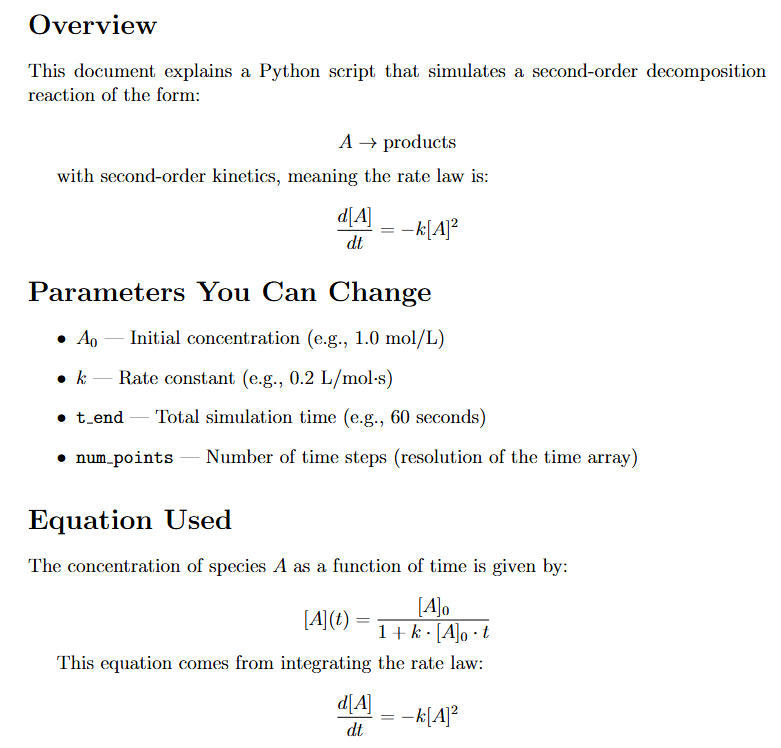

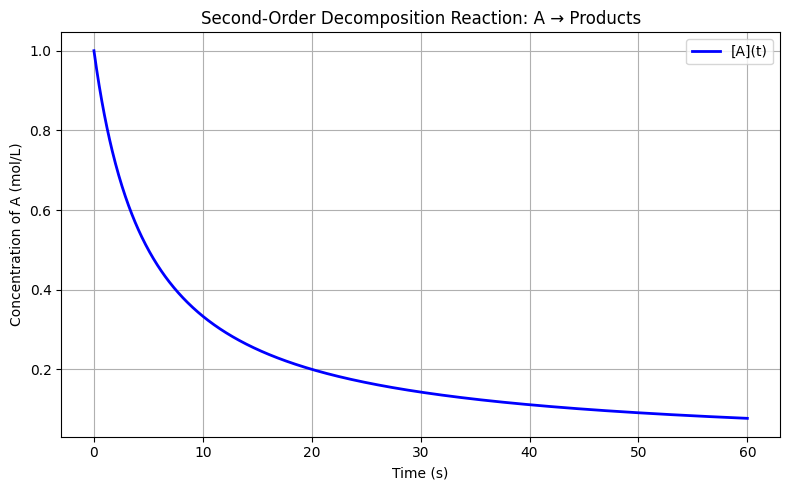

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (you can change these)
A0 = 1.0         # Initial concentration of A (mol/L)
k = 0.2          # Rate constant (L/mol·s)
t_end = 60       # Total time (s)
num_points = 1000  # Number of time steps

# Time array
t = np.linspace(0, t_end, num_points)

# Second-order kinetics: [A] = A0 / (1 + k * A0 * t)
A = A0 / (1 + k * A0 * t)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t, A, color='blue', linewidth=2, label='[A](t)')
plt.xlabel('Time (s)')
plt.ylabel('Concentration of A (mol/L)')
plt.title('Second-Order Decomposition Reaction: A → Products')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Equation: 1/[A] = 0.2000 * t + 1.0000
Rate constant (k): 0.2000 L/mol·s
Intercept (1/[A0]): 1.0000 L/mol
R²: 1.00000


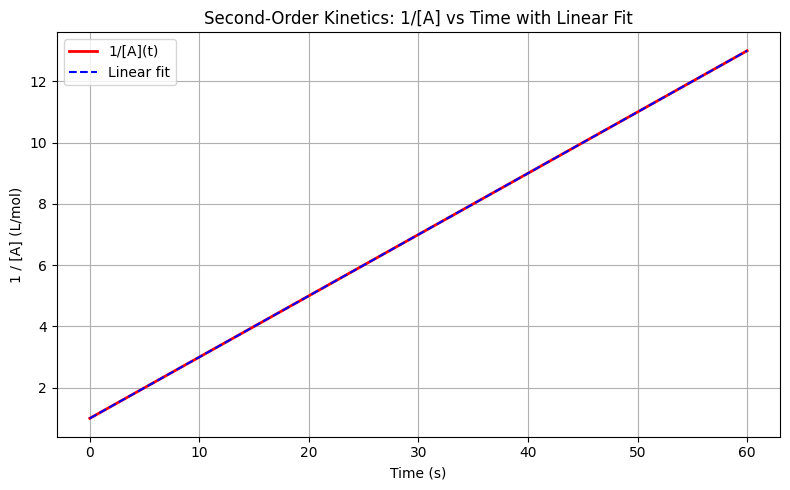

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Parameters
A0 = 1.0         # Initial concentration of A (mol/L)
k = 0.2          # Rate constant (L/mol·s)
t_end = 60       # Total time (s)
num_points = 1000  # Number of time steps

# Time array
t = np.linspace(0, t_end, num_points)

# Second-order kinetics: [A] = A0 / (1 + k * A0 * t)
A = A0 / (1 + k * A0 * t)

# Calculate 1/[A]
inv_A = 1 / A

# Linear regression: 1/[A] = k * t + 1/A0
slope, intercept, r_value, p_value, std_err = linregress(t, inv_A)

# Best-fit line for plotting
fit_line = slope * t + intercept

# Print the equation of the line
print(f"Equation: 1/[A] = {slope:.4f} * t + {intercept:.4f}")
print(f"Rate constant (k): {slope:.4f} L/mol·s")
print(f"Intercept (1/[A0]): {intercept:.4f} L/mol")
print(f"R²: {r_value**2:.5f}")

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t, inv_A, color='red', linewidth=2, label='1/[A](t)')
plt.plot(t, fit_line, color='blue', linestyle='--', label='Linear fit')
plt.xlabel('Time (s)')
plt.ylabel('1 / [A] (L/mol)')
plt.title('Second-Order Kinetics: 1/[A] vs Time with Linear Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


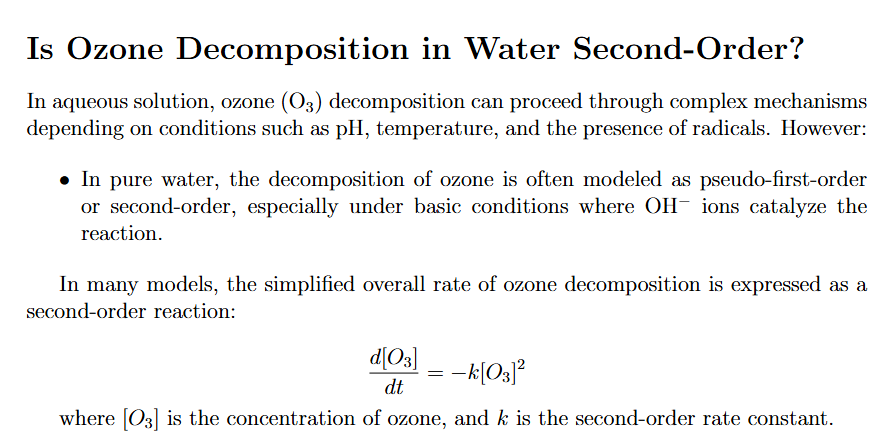

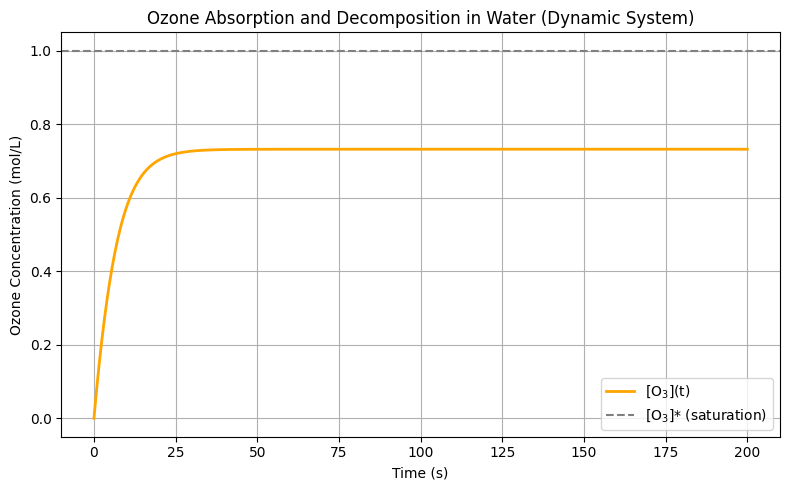

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters
k_d = 0.05      # Decomposition rate constant (1/s)
n = 2           # Reaction order
k_La = 0.1      # Mass transfer coefficient (1/s)
O3_star = 1.0   # Saturation concentration of ozone (mol/L)

# Time array
t = np.linspace(0, 200, 1000)  # Time range from 0 to 200 seconds

# Define the ODE system: d[O3]/dt = k_La([O3]* - [O3]) - k_d[O3]^n
def dO3_dt(O3, t, k_d, n, k_La, O3_star):
    r_decomp = k_d * O3**n                          # Ozone decomposition rate
    r_transfer = k_La * (O3_star - O3)              # Ozone absorption rate
    dO3 = r_transfer - r_decomp                     # Net rate of change
    return dO3

# Initial ozone concentration
O3_0 = 0.0  # Initially no ozone in the solution

# Solve the differential equation
O3_conc = odeint(dO3_dt, O3_0, t, args=(k_d, n, k_La, O3_star))

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t, O3_conc, label='[O$_3$](t)', linewidth=2, color='orange')
plt.axhline(y=O3_star, color='gray', linestyle='--', label='[O$_3$]* (saturation)')
plt.xlabel('Time (s)')
plt.ylabel('Ozone Concentration (mol/L)')
plt.title('Ozone Absorption and Decomposition in Water (Dynamic System)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


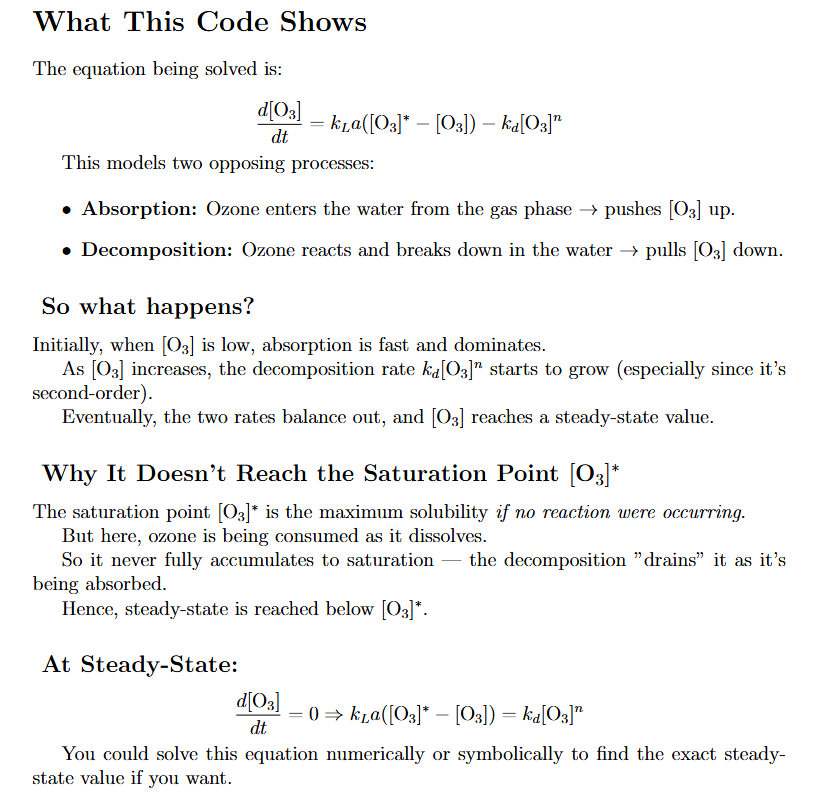

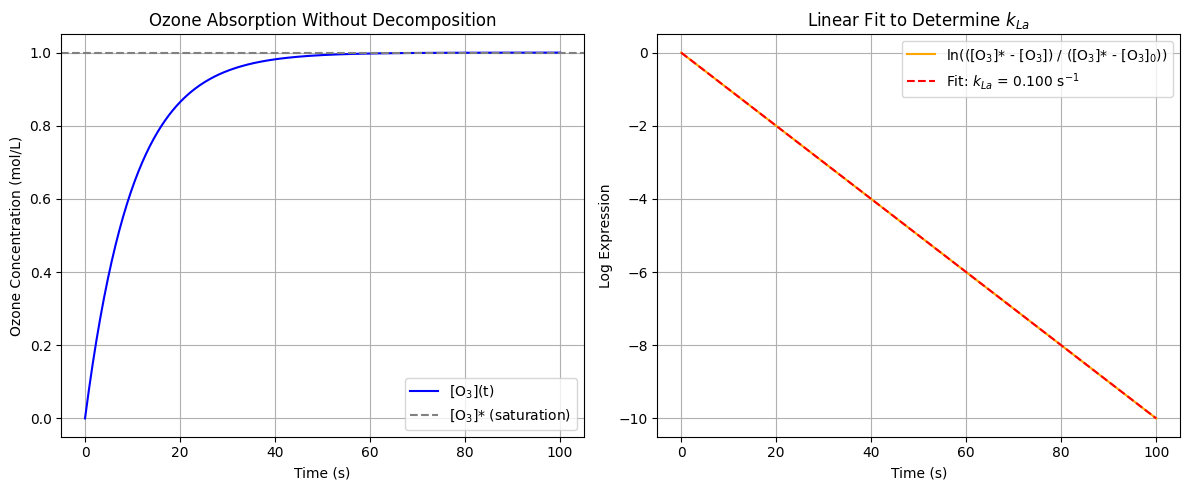

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
k_La_true = 0.1      # True mass transfer coefficient (1/s)
O3_star = 1.0        # Saturation concentration (mol/L)
O3_0 = 0.0           # Initial ozone concentration in water (mol/L)

# Time array
t = np.linspace(0, 100, 500)  # Time in seconds

# Analytical solution for [O3](t) without decomposition
def O3_no_decomp(t, k_La, O3_star, O3_0):
    return O3_star * (1 - np.exp(-k_La * t)) + O3_0 * np.exp(-k_La * t)

# Generate synthetic data
O3_conc = O3_no_decomp(t, k_La_true, O3_star, O3_0)

# Calculate log-transformed values for linear fit
log_y = np.log((O3_star - O3_conc) / (O3_star - O3_0))

# Fit a line to the transformed data
def linear_model(t, slope):
    return -slope * t

popt, _ = curve_fit(linear_model, t, log_y)
k_La_fitted = popt[0]

# Plot results
plt.figure(figsize=(12, 5))

# Subplot 1: [O3] vs Time
plt.subplot(1, 2, 1)
plt.plot(t, O3_conc, label='[O$_3$](t)', color='blue')
plt.axhline(O3_star, color='gray', linestyle='--', label='[O$_3$]* (saturation)')
plt.xlabel('Time (s)')
plt.ylabel('Ozone Concentration (mol/L)')
plt.title('Ozone Absorption Without Decomposition')
plt.grid(True)
plt.legend()

# Subplot 2: Log plot and linear fit
plt.subplot(1, 2, 2)
plt.plot(t, log_y, label='ln(([O$_3$]* - [O$_3$]) / ([O$_3$]* - [O$_3$]$_0$))', color='orange')
plt.plot(t, linear_model(t, *popt), '--', label=f'Fit: $k_{{La}}$ = {k_La_fitted:.3f} s$^{{-1}}$', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Log Expression')
plt.title('Linear Fit to Determine $k_{La}$')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


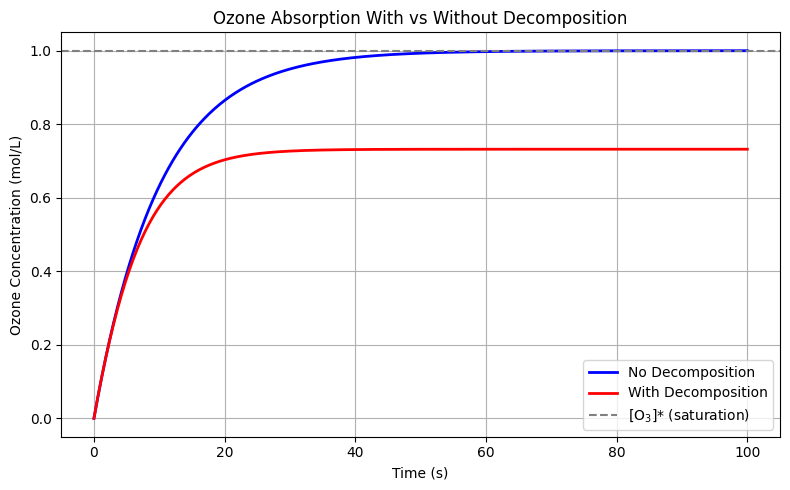

In [ ]:
# Updated O3 function with decomposition included
def O3_with_decomp(t, k_La, k_d, n, O3_star, O3_0):
    # Numerical solution using ODE integration
    from scipy.integrate import odeint

    def dO3_dt(O3, t, k_d, n, k_La, O3_star):
        r_decomp = k_d * O3**n
        r_transfer = k_La * (O3_star - O3)
        return r_transfer - r_decomp

    O3_conc = odeint(dO3_dt, O3_0, t, args=(k_d, n, k_La, O3_star))
    return O3_conc.flatten()

# Parameters with decomposition
k_d = 0.05  # Decomposition rate constant (1/s)
n = 2       # Reaction order

# Simulate data with decomposition
O3_conc_decomp = O3_with_decomp(t, k_La_true, k_d, n, O3_star, O3_0)

# Plot comparison
plt.figure(figsize=(8, 5))
plt.plot(t, O3_conc, label='No Decomposition', linewidth=2, color='blue')
plt.plot(t, O3_conc_decomp, label='With Decomposition', linewidth=2, color='red')
plt.axhline(O3_star, color='gray', linestyle='--', label='[O$_3$]* (saturation)')
plt.xlabel('Time (s)')
plt.ylabel('Ozone Concentration (mol/L)')
plt.title('Ozone Absorption With vs Without Decomposition')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The model uses only second-order decomposition (no mass transfer), just like the experimental setup.

The plot is linear for each curve:

1
[
𝑂
3
]
(
𝑡
)
−
1
[
𝑂
3
]
0
=
𝑘
𝑑
𝑡
[O
3
​
 ](t)
1
​
 −
[O
3
​
 ]
0
​

1
​
 =k
d
​
 t
confirming second-order kinetics.

Different lines simulate different pH conditions by varying
𝑘
𝑑
k
d
​
 . Higher pH ⇒ higher
𝑘
𝑑
k
d
​
  ⇒ steeper slope — matching the trend from pH 7.8 to 9.5 in the figure.

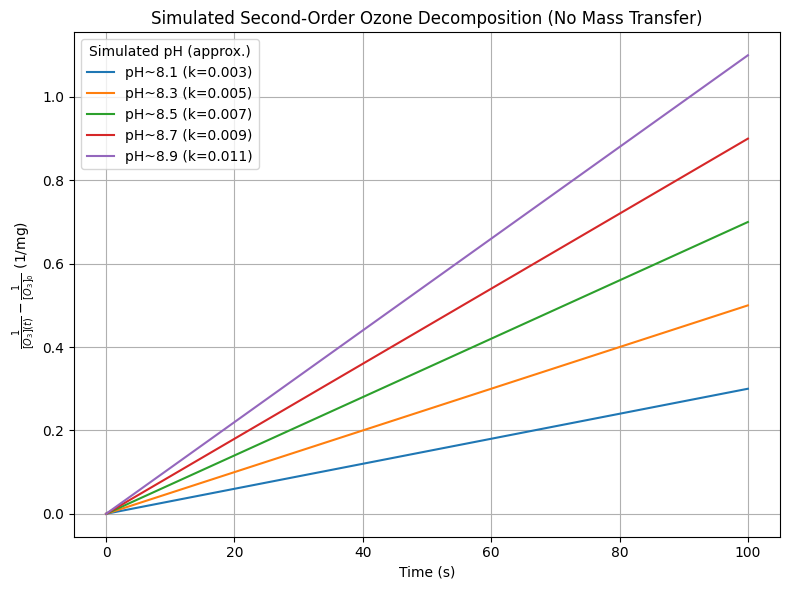

In [ ]:
# Pure decomposition model (no mass transfer)
def pure_decomp(O3, t, k_d):
    return -k_d * O3**2

# Initial ozone concentration (aligned with experimental values: 4.4–8.6 mg/L ≈ 0.09–0.18 mmol/L)
O3_0_values = [0.09, 0.11, 0.13, 0.15, 0.17]  # mol/m^3 equivalent
k_d_values = [0.003, 0.005, 0.007, 0.009, 0.011]  # Chosen to spread slopes

# Time array
t = np.linspace(0, 100, 500)

# Plotting
plt.figure(figsize=(8, 6))

for O3_0, k_d in zip(O3_0_values, k_d_values):
    O3_conc = odeint(pure_decomp, O3_0, t, args=(k_d,)).flatten()
    linearized = 1 / O3_conc - 1 / O3_0
    plt.plot(t, linearized, label=f'pH~{7.8 + k_d*100:.1f} (k={k_d:.3f})')

# Final touches
plt.xlabel('Time (s)')
plt.ylabel(r'$\frac{1}{[O_3](t)} - \frac{1}{[O_3]_0}$ (1/mg)')
plt.title('Simulated Second-Order Ozone Decomposition (No Mass Transfer)')
plt.grid(True)
plt.legend(title="Simulated pH (approx.)")
plt.tight_layout()
plt.show()


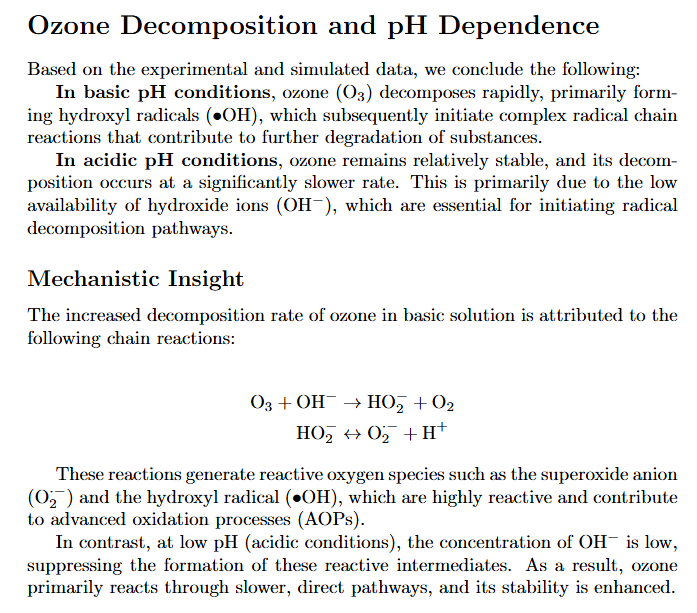